# uq-pet walkthrough

A thin tour of the pipeline. Every cell **imports** from `uq_pet.*` — nothing is
redefined here, so the notebook can't drift from the library. Run it from `notebooks/`;
the config path is relative.

The later cells call `main`'s stage functions directly. That is the one place this
notebook reaches into the entry point, and it is deliberate: re-implementing the
select/train/summarize loops here is exactly the drift the rest of the notebook avoids.
Nothing *in the package* imports `main`.

For the full run use:

```bash
uv run python -m uq_pet.main --config configs/nhr_gemma.yaml
```

In [1]:
%load_ext autoreload
%autoreload 2

from uq_pet.config import load_config
from uq_pet.dataset import download_pet_ner, sentence_key, split_dataset, to_examples
from uq_pet.prompt import build_system_prompt, build_user_prompts, prompt_fingerprint
from uq_pet import llm, uncertainty

# The full grid. Swap in ../configs/smoke.yaml for the fast tour: 1 budget, 3 arms,
# 1 training seed, 2 epochs — same cache, same code path.
cfg = load_config("../configs/nhr_gemma.yaml")
cfg

ExperimentConfig(budget_pct=[5.0, 10.0, 25.0, 30.0], arms=[ArmConfig(strategy='random', params={}, label=None), ArmConfig(strategy='avg_neg_logprob', params={'tokens': 'filtered'}, label=None), ArmConfig(strategy='avg_neg_logprob', params={'tokens': 'pure'}, label=None), ArmConfig(strategy='output_disagreement', params={'measure': 'vote_entropy'}, label=None), ArmConfig(strategy='output_disagreement', params={'measure': 'disagreement'}, label=None)], selection_seed=42, tie_seed=0, train_seeds=[0, 1], llm=LLMConfig(model='RedHatAI/gemma-4-31B-it-FP8-block', base_url='https://hub.nhr.fau.de/api/llmgw/v1', api_key_env='NHR_FAU_API_KEY', cache_prefix='nhr_gemma', cache_suffix='dist', n_samples=5, temperature=1.0, seed=0, max_tokens=256, logprobs=True, top_logprobs=None, workers=8, timeout=120.0, max_retries=5, limit=None), train=TrainConfig(checkpoint='distilbert-base-cased', epochs=20, batch_size=8, learning_rate=5e-05, weight_decay=0.01, warmup_fraction=0.1, max_length=256, eval_batch_si

## Data

Fixed split: 5 few-shot examples, a 328-sentence pool, 84 held-out test sentences.

In [2]:
download_pet_ner()
few_shot, pool, test = split_dataset()

pool_examples = to_examples(pool)
test_examples = to_examples(test)

print(len(few_shot), len(pool_examples), len(test_examples))
pool_examples[0]

5 328 84


{'document name': 'doc-1.1',
 'sentence-ID': 9,
 'tokens': ['In',
  'the',
  'meantime',
  ',',
  'the',
  'engineering',
  'department',
  'prepares',
  'everything',
  'for',
  'the',
  'assembling',
  'of',
  'the',
  'ordered',
  'bicycle',
  '.'],
 'ner-tags': [13, 14, 14, 0, 1, 2, 2, 3, 5, 0, 0, 0, 0, 0, 0, 0, 0]}

## Prompts

One constant system prefix (so it caches server-side) plus one user message per sentence.

In [3]:
system_prompt = build_system_prompt(few_shot)
user_prompts = build_user_prompts(pool_examples)
prompt_sha = prompt_fingerprint(system_prompt)

print(prompt_sha)
print(user_prompts[0])

6f9f69c64b96
Tokens to tag:
['In', 'the', 'meantime', ',', 'the', 'engineering', 'department', 'prepares', 'everything', 'for', 'the', 'assembling', 'of', 'the', 'ordered', 'bicycle', '.']

Output MUST be an array of integers with exactly 17 elements, one per
token, in order. Output nothing except the array.



## Scoring

`score_split` is resumable: it reads the cache, scores only what's missing, and never
builds a client when there's nothing to do. The cell below therefore makes **no API
calls** as long as the cache is complete.

In [4]:
records = llm.score_split(
    cfg.llm,
    system_prompt,
    user_prompts,
    [sentence_key(ex) for ex in pool_examples],
    cfg.llm.cache_path("pool"),
    prompt_sha,
)

print(f"{len(records)} records, {len(llm.failed_indices(records))} failed, "
      f"{llm.truncated_count(records)} truncated choices")
print(f"cache alignment: {llm.verify_cache_alignment(records, pool_examples):.3f}")

328 records, 0 failed, 13 truncated choices
cache alignment: 0.957


## Uncertainty

One score dict per arm, recomputed from the cache every time and never stored — so
metrics and budgets are free to change. `score_arm` dispatches on the arm's `strategy`
into the `METRICS` registry and passes the arm's YAML keys through as parameters; the
`random` control has no metric, so it scores `None`.

In [5]:
scores = {
    arm.resolved_label(): uncertainty.score_arm(arm.strategy, records, **arm.params)
    for arm in cfg.arms
}

label = next(a.resolved_label() for a in cfg.arms if a.strategy != uncertainty.RANDOM)
print(f"most uncertain by {label}:")
for idx in uncertainty.rank_by_uncertainty(scores[label], tie_seed=cfg.tie_seed)[:5]:
    print(f"  {scores[label][idx]:.3f}  {' '.join(pool_examples[idx]['tokens'])[:70]}")

most uncertain by avg_neg_logprob:filtered:
  0.248  An employee purchases a product or service he requires .
  0.231  In any case the system will send a notification to let the user know w
  0.176  Physicians use dictaphones to record their observations made during me
  0.166  The GO transmit the readings to the SP .
  0.163  While the kitchen and the sommelier are doing their tasks , the waiter


## Selection

`stage_select` returns one list of sentences per `(budget, arm)` cell. Within a budget
every arm gets the same number of sentences — only *which* ones differs — and
`stage_select` raises if that ever stops being true. Metric scores don't depend on the
budget, so each metric is scored once and reused across the sweep.

In [6]:
from uq_pet.main import stage_select, stage_train, summarize

cells = stage_select(cfg, records, pool_examples)

{f"{budget:g}% {arm}": len(examples) for (budget, arm), examples in cells.items()}

{'5% random': 16,
 '5% avg_neg_logprob:filtered': 16,
 '5% avg_neg_logprob:pure': 16,
 '5% output_disagreement:vote_entropy': 16,
 '5% output_disagreement:disagreement': 16,
 '10% random': 32,
 '10% avg_neg_logprob:filtered': 32,
 '10% avg_neg_logprob:pure': 32,
 '10% output_disagreement:vote_entropy': 32,
 '10% output_disagreement:disagreement': 32,
 '25% random': 82,
 '25% avg_neg_logprob:filtered': 82,
 '25% avg_neg_logprob:pure': 82,
 '25% output_disagreement:vote_entropy': 82,
 '25% output_disagreement:disagreement': 82,
 '30% random': 98,
 '30% avg_neg_logprob:filtered': 98,
 '30% avg_neg_logprob:pure': 98,
 '30% output_disagreement:vote_entropy': 98,
 '30% output_disagreement:disagreement': 98}

## Training

Each cell is fine-tuned from scratch and scored on the held-out split, then the model is
freed. This is the slow part: `nhr_gemma.yaml` is 4 budgets x 5 arms x 2 seeds = **40**
fine-tunes. `smoke.yaml` is 3.

In [7]:
from uq_pet.model_training import configure_hf_logging

configure_hf_logging(quiet=True)
results = stage_train(cfg, cells, test_examples)
results.drop(columns="per_type_f1")

,budget_pct,arm,seed,n_train,entity_f1,entity_precision,entity_recall,token_accuracy
0,5.0,random,0,16,0.281899,0.303514,0.263158,0.585714
1,5.0,random,1,16,0.274707,0.347458,0.227147,0.555280
2,5.0,avg_neg_logprob:filtered,0,16,0.021053,0.043860,0.013850,0.475155
3,5.0,avg_neg_logprob:filtered,1,16,0.077079,0.143939,0.052632,0.494410
4,5.0,avg_neg_logprob:pure,0,16,0.087824,0.157143,0.060942,0.532919
5,5.0,avg_neg_logprob:pure,1,16,0.240777,0.402597,0.171745,0.562112
6,5.0,output_disagreement:vote_entropy,0,16,0.209302,0.348387,0.149584,0.554037
7,5.0,output_disagreement:vote_entropy,1,16,0.241715,0.407895,0.171745,0.550311
8,5.0,output_disagreement:disagreement,0,16,0.256917,0.448276,0.180055,0.557143
9,5.0,output_disagreement:disagreement,1,16,0.265625,0.450331,0.188366,0.556522


In [8]:
import pandas as pd

summary, per_type, gaps = summarize(results)
display(summary)
display(per_type)

# entity-F1 gap vs. the random control, one row per budget. Empty if no random arm.
display(pd.DataFrame(gaps).T.rename_axis("budget %"))

entity_f1          \
                                                 mean     std   
budget_pct arm                                                  
5.0        avg_neg_logprob:filtered            0.0491  0.0396   
           avg_neg_logprob:pure                0.1643  0.1082   
           output_disagreement:disagreement    0.2613  0.0062   
           output_disagreement:vote_entropy    0.2255  0.0229   
           random                              0.2783  0.0051   
10.0       avg_neg_logprob:filtered            0.4713  0.0094   
           avg_neg_logprob:pure                0.4941  0.0125   
           output_disagreement:disagreement    0.5175  0.0091   
           output_disagreement:vote_entropy    0.5011  0.0079   
           random                              0.5458  0.0030   
25.0       avg_neg_logprob:filtered            0.6812  0.0032   
           avg_neg_logprob:pure                0.6753  0.0096   
           output_disagreement:disagreement    0.6616  0.0294   
           output_disagreement:vote_entropy    0.6757  0.0027   
           random                              0.6780  0.0098   
30.0       avg_neg_logprob:filtered            0.6952  0.0141   
           avg_neg_logprob:pure                0.7151  0.0137   
           output_disagreement:disagreement    0.7045  0.0005   
           output_disagreement:vote_entropy    0.6961  0.0240   
           random                              0.6945  0.0065   

                                            entity_precision          \
                                                        mean     std   
budget_pct arm                                                         
5.0        avg_neg_logprob:filtered                   0.0939  0.0708   
           avg_neg_logprob:pure                       0.2799  0.1736   
           output_disagreement:disagreement           0.4493  0.0015   
           output_disagreement:vote_entropy           0.3781  0.0421   
           random                                     0.3255  0.0311   
10.0       avg_neg_logprob:filtered                   0.4964  0.0162   
           avg_neg_logprob:pure                       0.5248  0.0060   
           output_disagreement:disagreement           0.5498  0.0033   
           output_disagreement:vote_entropy           0.5392  0.0130   
           random                                     0.4960  0.0024   
25.0       avg_neg_logprob:filtered                   0.6909  0.0038   
           avg_neg_logprob:pure                       0.6666  0.0076   
           output_disagreement:disagreement           0.6521  0.0442   
           output_disagreement:vote_entropy           0.6600  0.0159   
           random                                     0.6340  0.0139   
30.0       avg_neg_logprob:filtered                   0.6952  0.0087   
           avg_neg_logprob:pure                       0.7009  0.0173   
           output_disagreement:disagreement           0.6884  0.0099   
           output_disagreement:vote_entropy           0.6736  0.0245   
           random                                     0.6671  0.0030   

                                            entity_recall          \
                                                     mean     std   
budget_pct arm                                                      
5.0        avg_neg_logprob:filtered                0.0332  0.0274   
           avg_neg_logprob:pure                    0.1163  0.0783   
           output_disagreement:disagreement        0.1842  0.0059   
           output_disagreement:vote_entropy        0.1607  0.0157   
           random                                  0.2452  0.0255   
10.0       avg_neg_logprob:filtered                0.4488  0.0039   
           avg_neg_logprob:pure                    0.4668  0.0176   
           output_disagreement:disagreement        0.4889  0.0137   
           output_disagreement:vote_entropy        0.4681  0.0039   
           random                                  0.6066  0.00

budget_pct                                  5.0                        \
arm                     avg_neg_logprob:filtered avg_neg_logprob:pure   
entity type                                                             
Activity                                   0.009                0.098   
Activity Data                              0.041                0.139   
Actor                                      0.105                0.285   
Condition Specification                    0.000                0.000   
Further Specification                      0.000                0.000   
XOR Gateway                                0.000                0.000   

budget_pct                                                \
arm                     output_disagreement:disagreement   
entity type                                                
Activity                                           0.264   
Activity Data                                      0.184   
Actor                                              0.439   
Condition Specification                            0.000   
Further Specification                              0.000   
XOR Gateway                                        0.000   

budget_pct                                                       \
arm                     output_disagreement:vote_entropy random   
entity type                                                       
Activity                                           0.213  0.521   
Activity Data                                      0.159  0.159   
Actor                                              0.394  0.305   
Condition Specification                            0.000  0.000   
Further Specification                              0.000  0.000   
XOR Gateway                                        0.000  0.000   

budget_pct                                  10.0                       \
arm                     avg_neg_logprob:filtered avg_neg_logprob:pure   
entity type                                                             
Activity                                   0.663                0.684   
Activity Data                              0.308                0.304   
Actor                                      0.603                0.657   
Condition Specification                    0.000                0.000   
Further Specification                      0.000                0.000   
XOR Gateway                                0.000                0.000   

budget_pct                                                \
arm                     output_disagreement:disagreement   
entity type                                                
Activity                                           0.657   
Activity Data                                      0.365   
Actor                                              0.686   
Condition Specification                            0.056   
Further Specification                              0.000   
XOR Gateway                                        0.037   

budget_pct                                                       \
arm                     output_disagreement:vote_entropy random   
entity type                                                       
Activity                                           0.678  0.746   
Activity Data                                      0.333  0.319   
Actor                                              0.647  0.705   
Condition Specification                            0.000  0.253   
Further Specification                              0.000  0.000   
XOR Gateway                                        0.074  0.496   

budget_pct                                  25.0                       \
arm                     avg_neg_logprob:filtered avg_neg_logprob:pure   
entity type                                                             
Activity                                   0.816                0.828   
Activity Data                              0.560                0.560   
Actor                        

,avg_neg_logprob:filtered,avg_neg_logprob:pure,output_disagreement:disagreement,output_disagreement:vote_entropy
budget %,,,,
5.0,-0.2292,-0.1140,-0.0170,-0.0528
10.0,-0.0745,-0.0517,-0.0282,-0.0447
25.0,0.0031,-0.0027,-0.0165,-0.0023
30.0,0.0007,0.0206,0.0100,0.0016


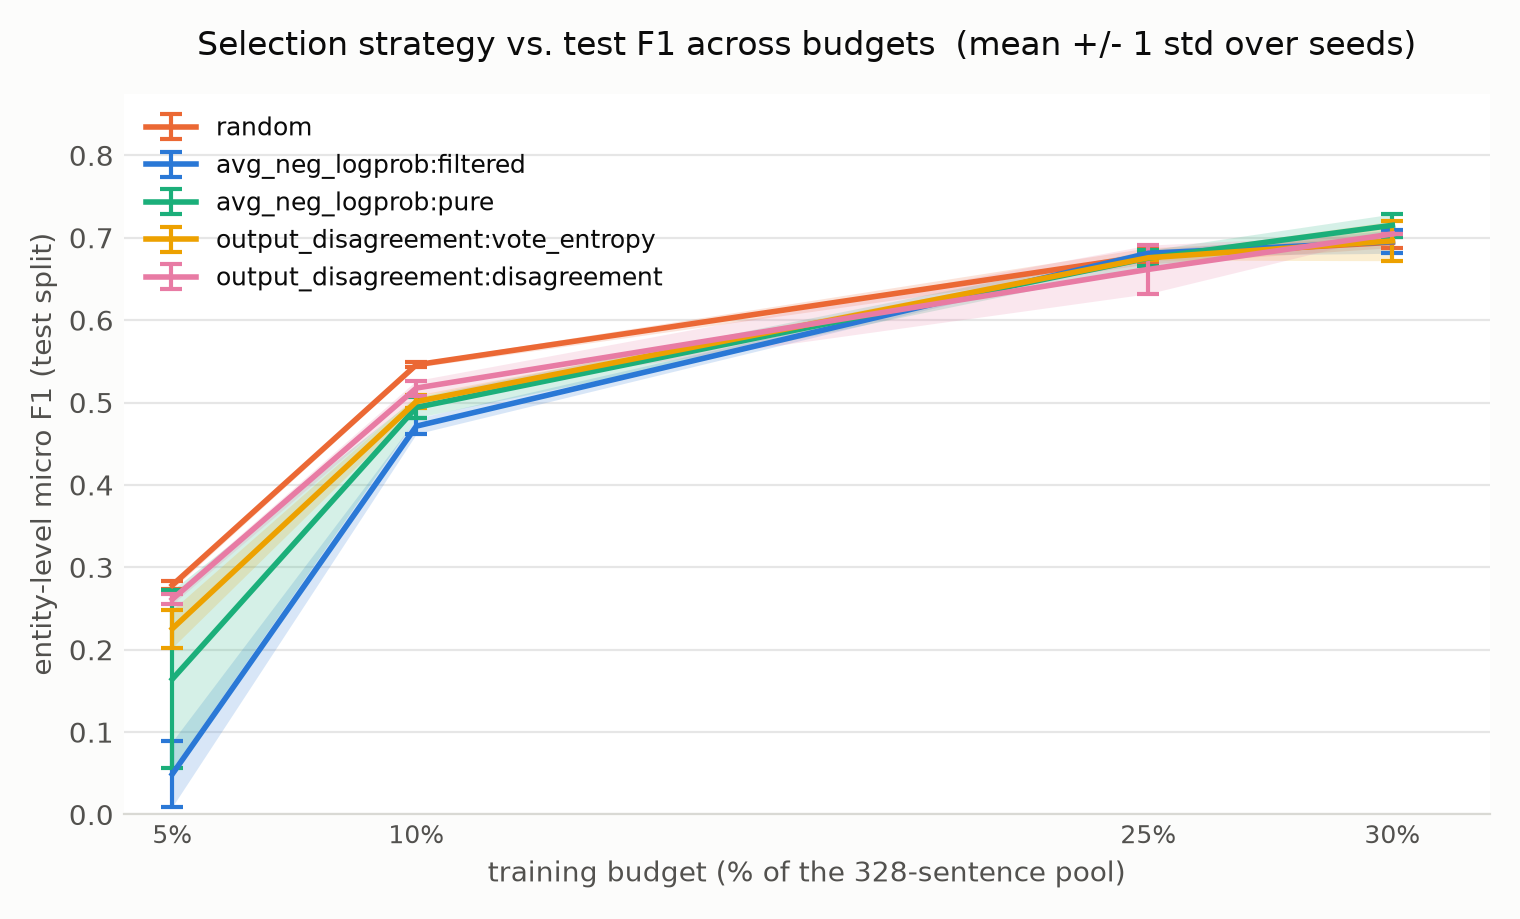

In [9]:
from pathlib import Path

from IPython.display import Image

from uq_pet.plotting import plot_results

out = Path("results.png")
plot_results(results, out)  # learning curve for a sweep, bars for a single budget
Image(str(out))